1. load the london full attractions
2. plot them on a map of london
3. try different clustering methods and parameters
4. visualise those clusters and pick 
(maybe NLP on the summaries and themes to help create useful labels for clusters)

In [1]:
import json
from pathlib import Path

import pandas as pd

DATA_FILE = Path("../data/london_full_attractions.json")

with open(DATA_FILE, "r", encoding="utf-8") as file:
    attractions = json.load(file)

df = pd.DataFrame(attractions)

print(f"Number of attractions: {len(df)}")
print(df.columns.tolist())

df.head()

Number of attractions: 404
['wikidata_id', 'name', 'category', 'description', 'latitude', 'longitude', 'image_url', 'sitelinks', 'summary', 'themes', 'interest_scores', 'recommended_visit_time', 'estimated_visit_mins', 'indoor', 'family_friendly', 'price_level']


,wikidata_id,name,category,description,latitude,longitude,image_url,sitelinks,summary,themes,interest_scores,recommended_visit_time,estimated_visit_mins,indoor,family_friendly,price_level
0,Q6373,British Museum,museum,"national museum in London, United Kingdom",51.519444,-0.126944,http://commons.wikimedia.org/wiki/Special:File...,108,The British Museum is a world-renowned museum ...,"[history, art, culture, ancient history]","{'history': 5, 'art': 5, 'architecture': 4, 'n...",morning,120,True,True,free
1,Q62378,Tower of London,museum,"castle in central London, United Kingdom",51.508200,-0.076198,http://commons.wikimedia.org/wiki/Special:File...,88,The Tower of London is a historic castle and m...,"[history, architecture, royalty, military hist...","{'history': 5, 'art': 3, 'architecture': 5, 'n...",morning,120,True,True,££
2,Q192988,Royal Observatory,museum,"observatory in Greenwich, London, UK",51.477833,-0.001389,http://commons.wikimedia.org/wiki/Special:File...,61,"The Royal Observatory in Greenwich, London, is...","[science, history, technology]","{'history': 4, 'art': 2, 'architecture': 3, 'n...",morning,60,True,True,£
3,Q674773,Science Museum,museum,"science museum in London, United Kingdom",51.497500,-0.174722,http://commons.wikimedia.org/wiki/Special:File...,47,The Science Museum in London is a world-renown...,"[science, technology, history, education]","{'history': 4, 'art': 2, 'architecture': 2, 'n...",morning,120,True,True,£
4,Q1990172,Sherlock Holmes Museum,museum,"museum in London, England",51.523694,-0.161000,http://commons.wikimedia.org/wiki/Special:File...,28,"The Sherlock Holmes Museum, located at 221B Ba...","[literature, history, entertainment]","{'history': 3, 'art': 2, 'architecture': 1, 'n...",morning,45,True,True,£


remove attractions with the same name

In [2]:
# remove duplicates based on name, keeping the first occurrence
df = df.drop_duplicates(subset="name", keep="first")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400 entries, 0 to 403
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   wikidata_id             400 non-null    object 
 1   name                    400 non-null    object 
 2   category                400 non-null    object 
 3   description             400 non-null    object 
 4   latitude                400 non-null    float64
 5   longitude               400 non-null    float64
 6   image_url               335 non-null    object 
 7   sitelinks               400 non-null    int64  
 8   summary                 400 non-null    object 
 9   themes                  400 non-null    object 
 10  interest_scores         400 non-null    object 
 11  recommended_visit_time  400 non-null    object 
 12  estimated_visit_mins    400 non-null    int64  
 13  indoor                  400 non-null    bool   
 14  family_friendly         400 non-null    bool   

In [4]:
df[["latitude", "longitude"]].describe()

,latitude,longitude
count,400.000000,400.000000
mean,51.497950,-0.118954
std,0.075790,0.148042
min,51.281940,-0.541403
25%,51.458844,-0.185334
50%,51.506217,-0.120360
75%,51.534964,-0.064557
max,51.696240,0.286358


In [5]:
duplicate_coordinates = df.duplicated(
    subset=["latitude", "longitude"],
    keep=False,
)

print(
    f"Attractions sharing coordinates: "
    f"{duplicate_coordinates.sum()}"
)

df.loc[
    duplicate_coordinates,
    ["name", "latitude", "longitude"],
].sort_values(["latitude", "longitude"])

Attractions sharing coordinates: 0


,name,latitude,longitude


no attractions have exactly the same long and lat which is good

remove attarctions that are not in the London Boundary

In [6]:
# remove attractions that are not in the London boundaries
from pathlib import Path
import geopandas as gpd

BOROUGHS_FILE = Path("data/London_Boroughs.gpkg")

london_boroughs = gpd.read_file(BOROUGHS_FILE)

print(london_boroughs.crs)
print(len(london_boroughs))
print(london_boroughs.columns)

london_boroughs.head()

EPSG:27700
33
Index(['objectid', 'name', 'gss_code', 'hectares', 'nonld_area', 'ons_inner',
       'sub_2011', 'geometry'],
      dtype='object')


,objectid,name,gss_code,hectares,nonld_area,ons_inner,sub_2011,geometry
0,1,Kingston upon Thames,E09000021,3726.117,0.000,F,South,"POLYGON ((516401.6 160201.8, 516407.3 160210.5..."
1,2,Croydon,E09000008,8649.441,0.000,F,South,"POLYGON ((535009.2 159504.7, 535005.5 159502, ..."
2,3,Bromley,E09000006,15013.487,0.000,F,South,"POLYGON ((540373.6 157530.4, 540361.2 157551.9..."
3,4,Hounslow,E09000018,5658.541,60.755,F,West,"POLYGON ((509703.4 175356.6, 509712.6 175361.8..."
4,5,Ealing,E09000009,5554.428,0.000,F,West,"POLYGON ((515647.2 178787.8, 515608.8 178787.3..."


go from long and lat to metres so clustering makes more sense 

In [7]:
import geopandas as gpd

attractions_gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(
        df["longitude"],
        df["latitude"],
    ),
    crs="EPSG:4326",
)

# Convert latitude/longitude into British National Grid coordinates
attractions_gdf = attractions_gdf.to_crs("EPSG:27700")

attractions_gdf["x"] = attractions_gdf.geometry.x
attractions_gdf["y"] = attractions_gdf.geometry.y

attractions_gdf[
    ["name", "latitude", "longitude", "x", "y"]
].head()

,name,latitude,longitude,x,y
0,British Museum,51.519444,-0.126944,530053.837805,181720.997798
1,Tower of London,51.508200,-0.076198,533607.325066,180561.921461
2,Royal Observatory,51.477833,-0.001389,538890.772252,177324.223271
3,Science Museum,51.497500,-0.174722,526800.012890,179196.924504
4,Sherlock Holmes Museum,51.523694,-0.161000,527679.286094,182133.689494


In [8]:
london_boroughs = london_boroughs.to_crs("EPSG:27700")

greater_london_boundary = london_boroughs.geometry.union_all()

inside_london = attractions_gdf.geometry.apply(
    greater_london_boundary.covers
)

london_gdf = attractions_gdf.loc[inside_london].copy()
outside_london_gdf = attractions_gdf.loc[~inside_london].copy()

print(f"Original attractions: {len(attractions_gdf)}")
print(f"Inside Greater London: {len(london_gdf)}")
print(f"Outside Greater London: {len(outside_london_gdf)}")

Original attractions: 400
Inside Greater London: 358
Outside Greater London: 42


lets see the outside london attractions

In [9]:
outside_london_gdf[
    ["name", "latitude", "longitude"]
].sort_values("name")

,name,latitude,longitude
190,"A preceptory of the Knights Hospitallers, know...",51.410300,0.240435
192,Anglo-Saxon cemetery at Darenth Park,51.433200,0.251256
189,"Bronze Age settlement, W of Runnymede Bridge",51.437200,-0.536206
280,Chenies Manor House,51.674400,-0.532966
34,Chiltern Open Air Museum,51.636400,-0.541403
279,Claremont Landscape Garden,51.357900,-0.378100
293,Copped Hall Gardens,51.692640,0.070300
170,Darenth Roman villa,51.412948,0.246371
361,Dartford Heath,51.435700,0.189270
56,Dartford Library,51.443100,0.218889


so I am now working with the london_gdf dataset

In [10]:
london_gdf.head()

,wikidata_id,name,category,description,latitude,longitude,image_url,sitelinks,summary,themes,interest_scores,recommended_visit_time,estimated_visit_mins,indoor,family_friendly,price_level,geometry,x,y
0,Q6373,British Museum,museum,"national museum in London, United Kingdom",51.519444,-0.126944,http://commons.wikimedia.org/wiki/Special:File...,108,The British Museum is a world-renowned museum ...,"[history, art, culture, ancient history]","{'history': 5, 'art': 5, 'architecture': 4, 'n...",morning,120,True,True,free,POINT (530053.838 181720.998),530053.837805,181720.997798
1,Q62378,Tower of London,museum,"castle in central London, United Kingdom",51.508200,-0.076198,http://commons.wikimedia.org/wiki/Special:File...,88,The Tower of London is a historic castle and m...,"[history, architecture, royalty, military hist...","{'history': 5, 'art': 3, 'architecture': 5, 'n...",morning,120,True,True,££,POINT (533607.325 180561.921),533607.325066,180561.921461
2,Q192988,Royal Observatory,museum,"observatory in Greenwich, London, UK",51.477833,-0.001389,http://commons.wikimedia.org/wiki/Special:File...,61,"The Royal Observatory in Greenwich, London, is...","[science, history, technology]","{'history': 4, 'art': 2, 'architecture': 3, 'n...",morning,60,True,True,£,POINT (538890.772 177324.223),538890.772252,177324.223271
3,Q674773,Science Museum,museum,"science museum in London, United Kingdom",51.497500,-0.174722,http://commons.wikimedia.org/wiki/Special:File...,47,The Science Museum in London is a world-renown...,"[science, technology, history, education]","{'history': 4, 'art': 2, 'architecture': 2, 'n...",morning,120,True,True,£,POINT (526800.013 179196.925),526800.012890,179196.924504
4,Q1990172,Sherlock Holmes Museum,museum,"museum in London, England",51.523694,-0.161000,http://commons.wikimedia.org/wiki/Special:File...,28,"The Sherlock Holmes Museum, located at 221B Ba...","[literature, history, entertainment]","{'history': 3, 'art': 2, 'architecture': 1, 'n...",morning,45,True,True,£,POINT (527679.286 182133.689),527679.286094,182133.689494


In [11]:
import folium

london_map = folium.Map(
    location=[51.5074, -0.1278],
    zoom_start=10,
    tiles="CartoDB positron",
)

for _, attraction in df.iterrows():
    folium.CircleMarker(
        location=[
            attraction["latitude"],
            attraction["longitude"],
        ],
        radius=4,
        popup=folium.Popup(
            attraction["name"],
            max_width=250,
        ),
        tooltip=attraction["name"],
        color="#2563eb",
        fill=True,
        fill_color="#2563eb",
        fill_opacity=0.7,
    ).add_to(london_map)

london_map.save("data/london+outside_attractions_map.html")
london_map

just the London attarctions

In [12]:
import folium

london_map = folium.Map(
    location=[51.5074, -0.1278],
    zoom_start=10,
    tiles="CartoDB positron",
)

for _, attraction in london_gdf.iterrows():
    folium.CircleMarker(
        location=[
            attraction["latitude"],
            attraction["longitude"],
        ],
        radius=4,
        popup=folium.Popup(
            attraction["name"],
            max_width=250,
        ),
        tooltip=attraction["name"],
        color="#2563eb",
        fill=True,
        fill_color="#2563eb",
        fill_opacity=0.7,
    ).add_to(london_map)

london_map.save("data/london_attractions_map.html")
london_map

I dont think DBSCAN is a good fit for this project as it will treat some of the data as noise, but I want all of these data points to be considered as genuine attractions and options so I think K means is a better fit. 

lets have a look at the elbow curve for K means using inertia

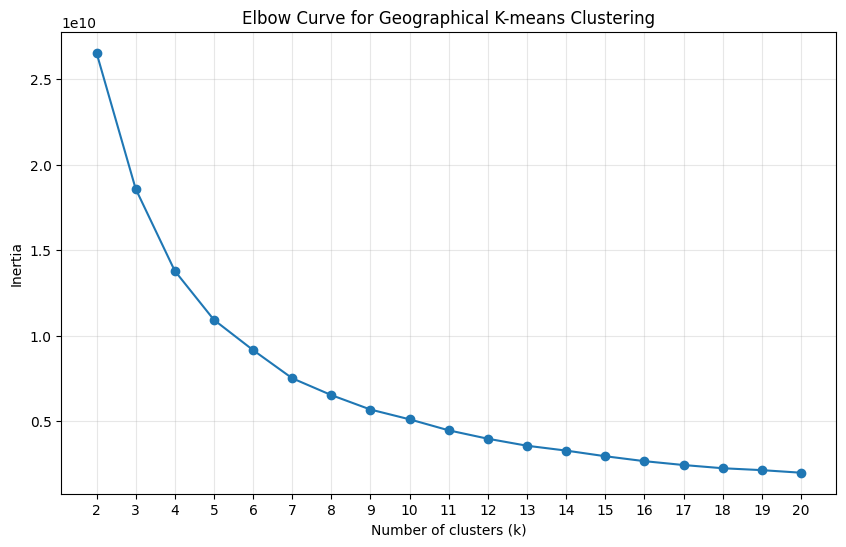

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

coordinates = london_gdf[["x", "y"]]

k_values = range(2, 21)
inertias = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20,
    )

    model.fit(coordinates)
    inertias.append(model.inertia_)

plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    inertias,
    marker="o",
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Curve for Geographical K-means Clustering")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.show()

and also the silhouette score

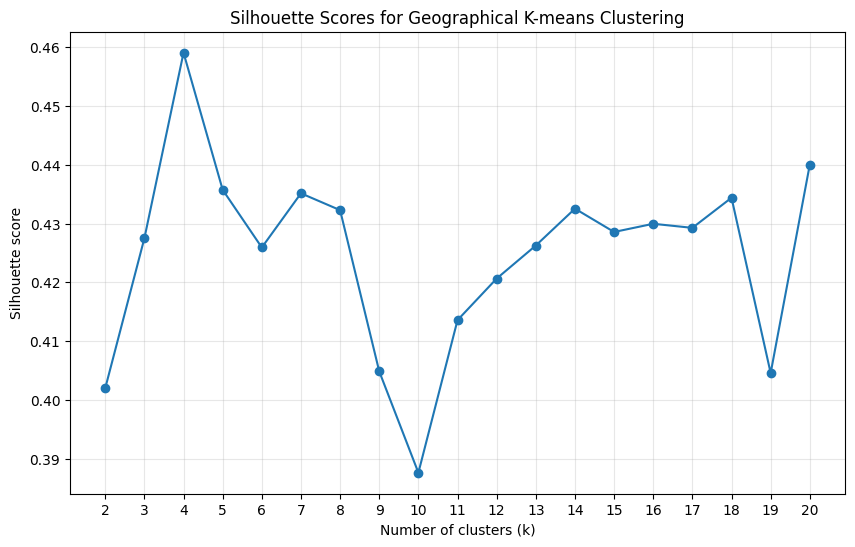

In [14]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20,
    )

    labels = model.fit_predict(coordinates)

    silhouette_scores.append(
        silhouette_score(coordinates, labels)
    )

plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o",
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Scores for Geographical K-means Clustering")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.show()

lets see what different K will look like

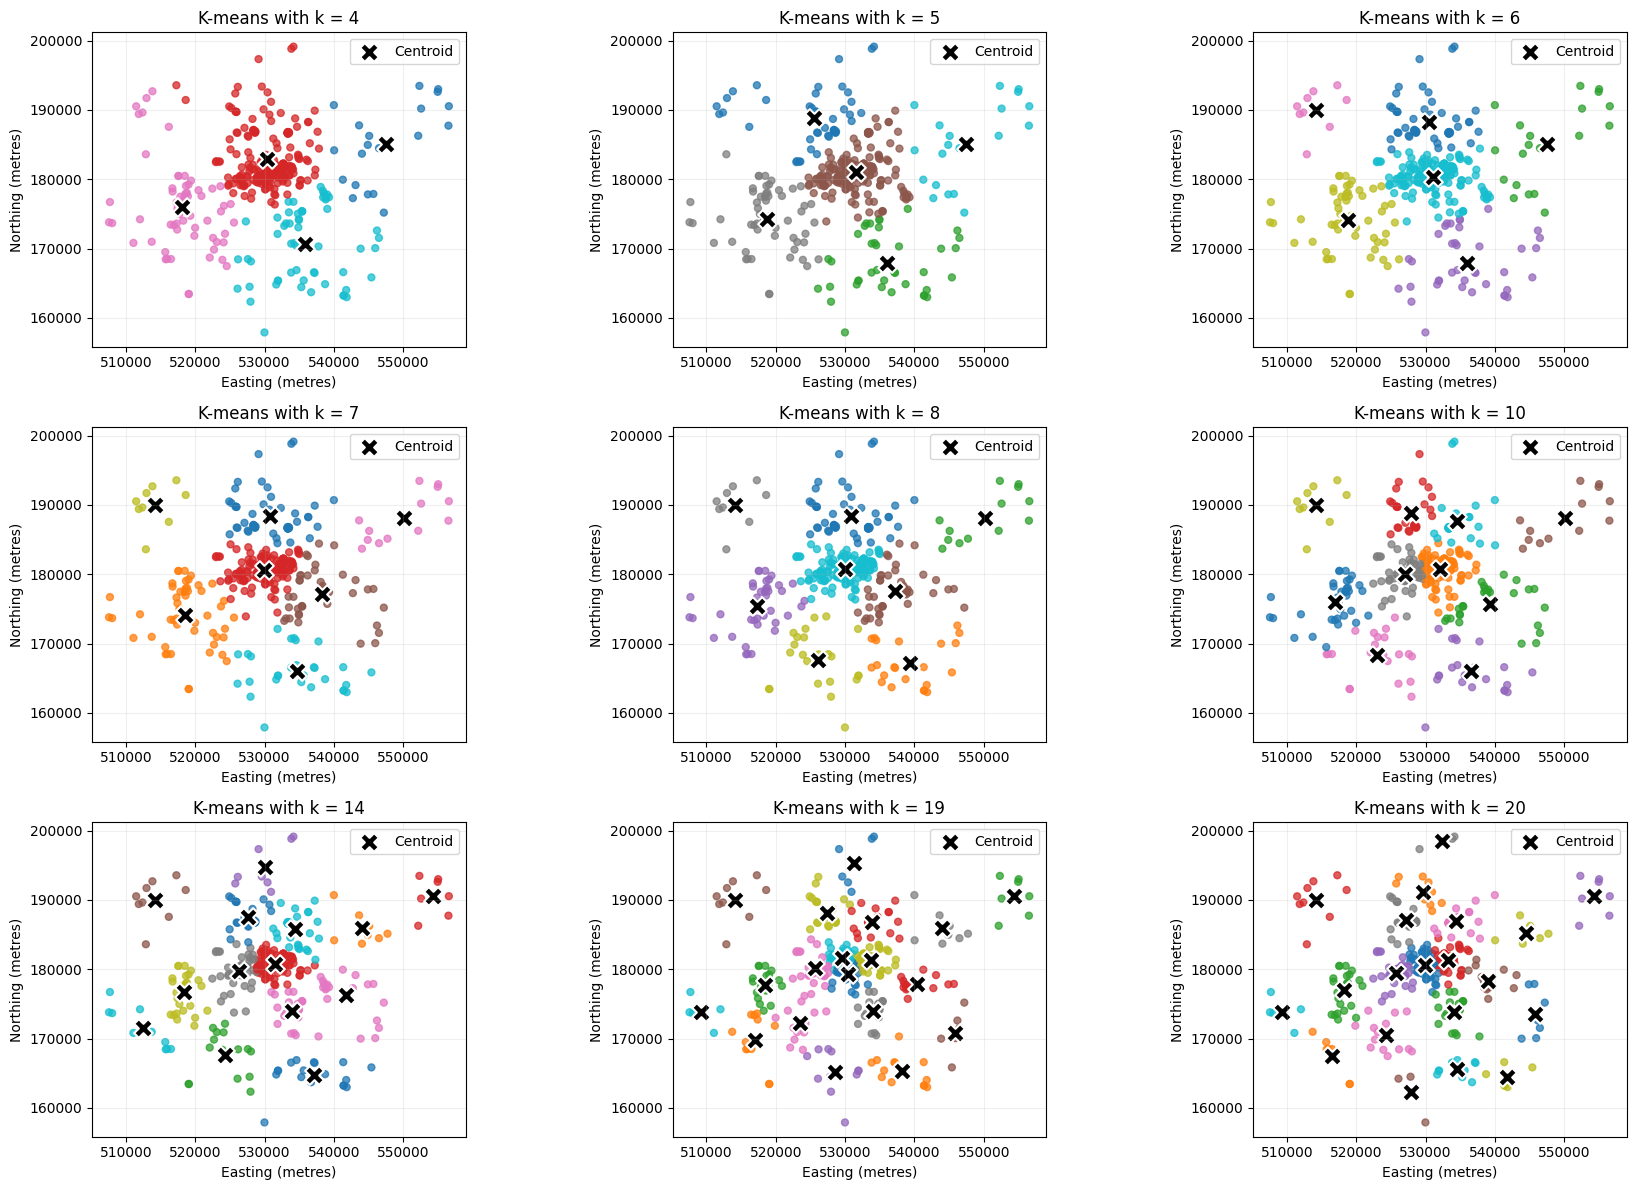

In [15]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

candidate_k_values = [4, 5, 6, 7, 8, 10, 14, 19, 20]

coordinates = london_gdf[["x", "y"]]

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(18, 12),
)

axes = axes.flatten()

for ax, k in zip(axes, candidate_k_values):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20,
    )

    labels = model.fit_predict(coordinates)
    centroids = model.cluster_centers_

    # Plot attractions, coloured by cluster
    scatter = ax.scatter(
        london_gdf["x"],
        london_gdf["y"],
        c=labels,
        cmap="tab10",
        s=25,
        alpha=0.75,
    )

    # Plot cluster centroids
    ax.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="X",
        s=180,
        c="black",
        edgecolors="white",
        linewidths=1.5,
        label="Centroid",
    )

    ax.set_title(f"K-means with k = {k}")
    ax.set_xlabel("Easting (metres)")
    ax.set_ylabel("Northing (metres)")
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)
    ax.legend()

plt.tight_layout()
plt.show()

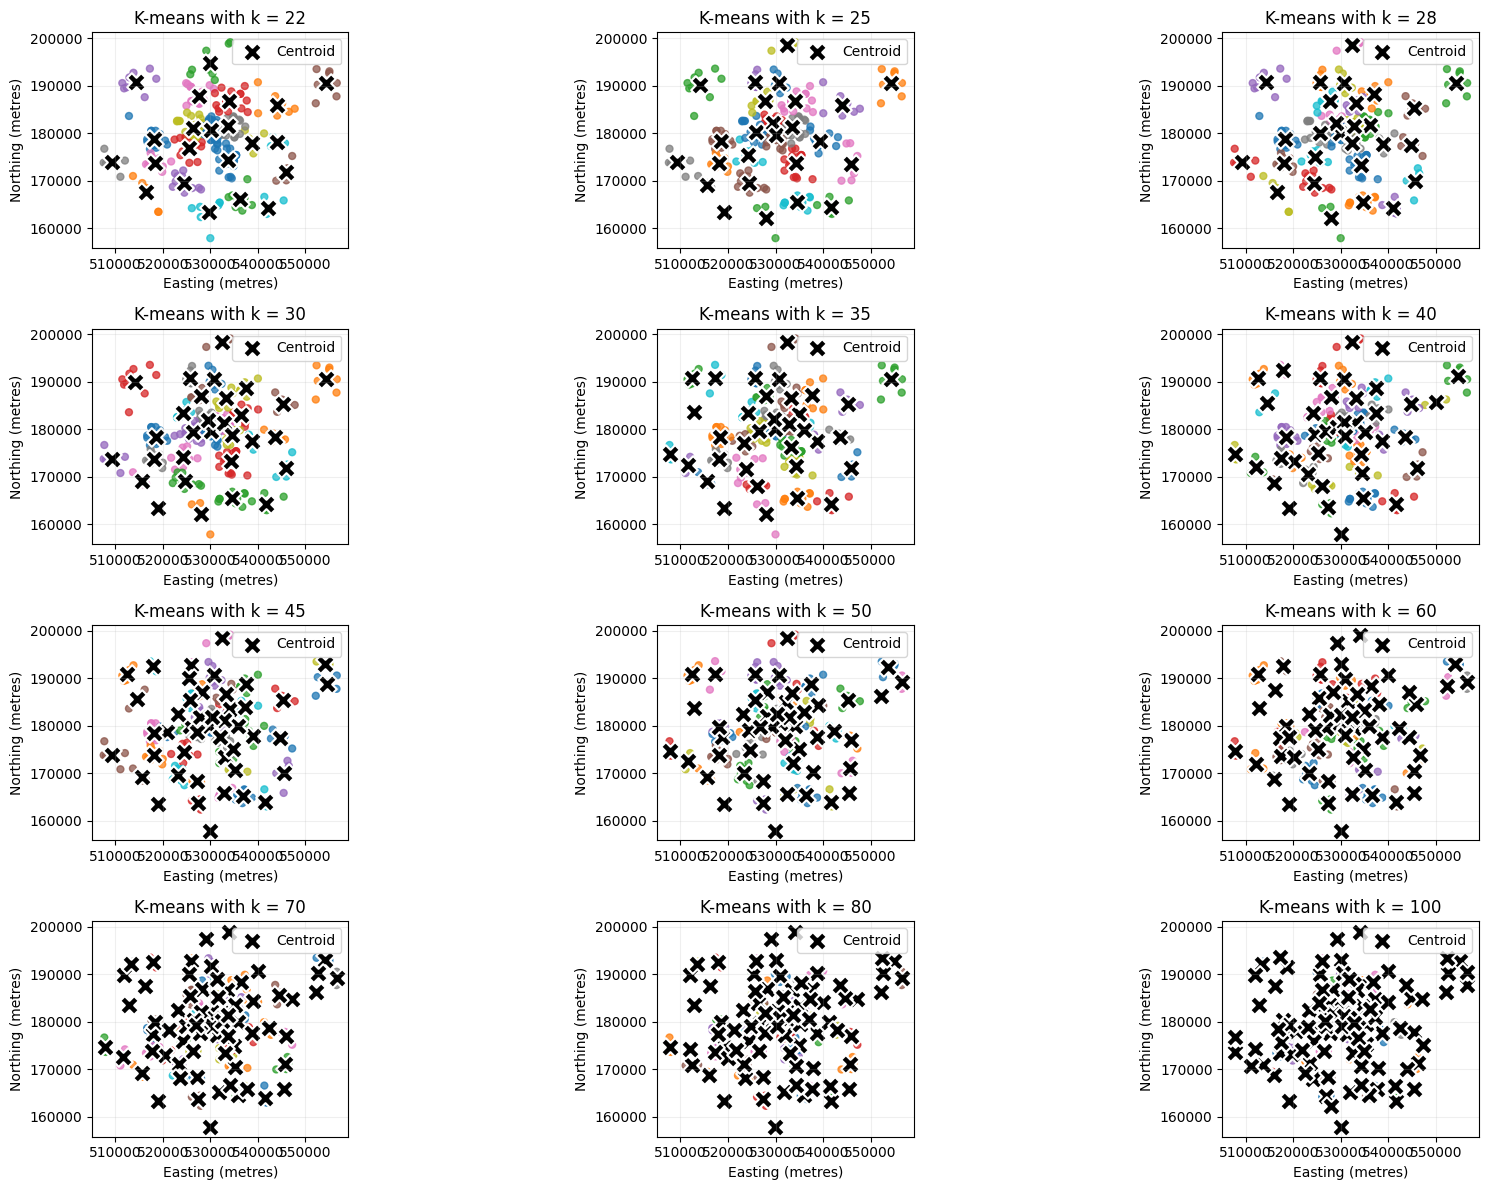

In [16]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

candidate_k_values = [22, 25, 28, 30, 35, 40, 45, 50, 60, 70, 80, 100]

coordinates = london_gdf[["x", "y"]]

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(18, 12),
)

axes = axes.flatten()

for ax, k in zip(axes, candidate_k_values):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20,
    )

    labels = model.fit_predict(coordinates)
    centroids = model.cluster_centers_

    # Plot attractions, coloured by cluster
    scatter = ax.scatter(
        london_gdf["x"],
        london_gdf["y"],
        c=labels,
        cmap="tab10",
        s=25,
        alpha=0.75,
    )

    # Plot cluster centroids
    ax.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="X",
        s=180,
        c="black",
        edgecolors="white",
        linewidths=1.5,
        label="Centroid",
    )

    ax.set_title(f"K-means with k = {k}")
    ax.set_xlabel("Easting (metres)")
    ax.set_ylabel("Northing (metres)")
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)
    ax.legend()

plt.tight_layout()
plt.show()

i liked the 20-35 range as it splits the attarctions in central london a lot rather than keeping it as 1 big cluster

In [17]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

candidate_k_values = [20, 22, 23, 24, 25, 28, 30, 32,35]
all_statistics = []
    
for k in candidate_k_values:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=20,
    )

    labels = model.fit_predict(coordinates)
    centroids = model.cluster_centers_

    distances_km = (
        np.linalg.norm(
            coordinates.to_numpy() - centroids[labels],
            axis=1,
        )
        / 1000
    )

    results = pd.DataFrame({
        "cluster_id": labels,
        "distance_km": distances_km,
    })

    cluster_stats = (
        results.groupby("cluster_id")
        .agg(
            attraction_count=("cluster_id", "size"),
            mean_distance_km=("distance_km", "mean"),
            max_distance_km=("distance_km", "max"),
        )
        .reset_index()
    )

    summary = {
        "k": k,
        "smallest_cluster": cluster_stats["attraction_count"].min(),
        "largest_cluster": cluster_stats["attraction_count"].max(),
        "median_cluster_size": cluster_stats["attraction_count"].median(),
        "mean_max_distance_km": cluster_stats["max_distance_km"].mean(),
        "largest_max_distance_km": cluster_stats["max_distance_km"].max(),
    }

    all_statistics.append(summary)

pd.DataFrame(all_statistics).round(2)

,k,smallest_cluster,largest_cluster,median_cluster_size,mean_max_distance_km,largest_max_distance_km
0,20,3,71,9.5,4.45,6.71
1,22,4,69,10.0,4.20,7.21
2,23,3,65,11.0,4.11,6.54
3,24,3,62,9.5,3.92,7.77
4,25,2,50,9.0,3.67,6.54
5,28,3,46,9.0,3.60,7.21
6,30,2,46,8.5,3.13,6.54
7,32,2,62,7.0,3.01,5.71
8,35,1,41,7.0,2.66,4.78


i want each cluster to have at least 3 to do a top 3 of the closest matched cluster to a user. so lets use 28 for now

In [18]:
final_model = KMeans(
    n_clusters=28,
    init="k-means++",
    random_state=42,
    n_init=20,
)

london_gdf["cluster_id"] = final_model.fit_predict(
    london_gdf[["x", "y"]]
)

plot this on follium

In [19]:
from matplotlib.colors import to_hex

K = 28
# Generate 25 distinct colours
colour_map = plt.get_cmap("gist_ncar", K)

cluster_colours = {
    cluster_id: to_hex(colour_map(cluster_id))
    for cluster_id in range(K)
}

# convert the centroids back to latitude/longitude for mapping
centroids_gdf = gpd.GeoDataFrame(
    {
        "cluster_id": range(K),
    },
    geometry=gpd.points_from_xy(
        final_model.cluster_centers_[:, 0],
        final_model.cluster_centers_[:, 1],
    ),
    crs="EPSG:27700",
).to_crs("EPSG:4326")


# Create a folium map to visualize the clusters
cluster_map_28 = folium.Map(
    location=[51.5074, -0.1278],
    zoom_start=10,
    tiles="CartoDB positron",
)

for _, attraction in london_gdf.iterrows():
    cluster_id = int(attraction["cluster_id"])
    colour = cluster_colours[cluster_id]

    popup_text = (
        f"<b>{attraction['name']}</b><br>"
        f"Cluster: {cluster_id}<br>"
        f"Category: {attraction['category']}"
    )

    folium.CircleMarker(
        location=[
            attraction["latitude"],
            attraction["longitude"],
        ],
        radius=5,
        color=colour,
        fill=True,
        fill_color=colour,
        fill_opacity=0.8,
        tooltip=(
            f"{attraction['name']} — "
            f"Cluster {cluster_id}"
        ),
        popup=folium.Popup(
            popup_text,
            max_width=300,
        ),
    ).add_to(cluster_map_28)

# Add cluster centroids to the map
for _, centroid in centroids_gdf.iterrows():
    cluster_id = int(centroid["cluster_id"])

    cluster_size = int(
        (london_gdf["cluster_id"] == cluster_id).sum()
    )

    folium.Marker(
        location=[
            centroid.geometry.y,
            centroid.geometry.x,
        ],
        tooltip=(
            f"Cluster {cluster_id} centroid "
            f"({cluster_size} attractions)"
        ),
        icon=folium.DivIcon(
            html=f"""
                <div style="
                    background-color: black;
                    color: white;
                    border: 2px solid white;
                    border-radius: 50%;
                    width: 30px;
                    height: 30px;
                    text-align: center;
                    line-height: 26px;
                    font-weight: bold;
                    font-size: 12px;
                ">
                    {cluster_id}
                </div>
            """
        ),
    ).add_to(cluster_map_28)

cluster_map_28.save("data/london_attractions_clusters_k28.html")
cluster_map_28


In [20]:
# i want to see the attarctions that have cluster id 27 as on the map it doesnt seem to have any attarctions
london_gdf[london_gdf["cluster_id"] == 27][["name", "latitude", "longitude"]].sort_values("name")

,name,latitude,longitude
38,Crofton Roman Villa,51.373100,0.087688
66,Metropolitan Police Museum,51.433676,0.101959
251,Prince Imperial Monument,51.410747,0.067099
167,Scadbury Manor moated site and fishponds,51.410900,0.097377
266,Sheffield Monument (In Churchyard Of Parish Ch...,51.423992,0.105614


lets try DBSCAN quickly and compare

In [21]:
from sklearn.cluster import DBSCAN

eps_values = [500, 750, 1000, 1250, 1500, 2000, 2500]
min_samples_values = [3, 4, 5]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        model = DBSCAN(
            eps=eps,
            min_samples=min_samples,
        )

        labels = model.fit_predict(coordinates)

        number_of_clusters = len(
            set(labels) - {-1}
        )

        noise_count = (labels == -1).sum()
        noise_percentage = (
            noise_count / len(labels)
        ) * 100

        non_noise_mask = labels != -1

        if (
            number_of_clusters >= 2
            and non_noise_mask.sum() > number_of_clusters
        ):
            score = silhouette_score(
                coordinates.loc[non_noise_mask],
                labels[non_noise_mask],
            )
        else:
            score = None

        dbscan_results.append({
            "eps_metres": eps,
            "min_samples": min_samples,
            "clusters": number_of_clusters,
            "noise_points": noise_count,
            "noise_percentage": noise_percentage,
            "silhouette_score": score,
        })

dbscan_results_df = pd.DataFrame(dbscan_results)

dbscan_results_df.round(3)

,eps_metres,min_samples,clusters,noise_points,noise_percentage,silhouette_score
0,500,3,18,200,55.866,0.566
1,500,4,12,223,62.291,0.565
2,500,5,10,248,69.274,0.631
3,750,3,19,159,44.413,0.437
4,750,4,11,187,52.235,0.398
5,750,5,7,206,57.542,0.466
6,1000,3,21,132,36.872,0.437
7,1000,4,12,160,44.693,0.450
8,1000,5,8,177,49.441,0.496
9,1250,3,22,99,27.654,0.318


DBSCAN still doesnt seem like a good fit for this project because of it classifying a lot of attarctions as noise and also the low noise tests have very few clusters. So K means where K=28 seems to be a better fit

testing NLP on eack cluster to create useful labels

1. combine the summary and themes 
2. TF-IDF to get the most distinctive words and phrases
3. combine it with the most dominant borough name 

In [22]:
london_gdf.head()

,wikidata_id,name,category,description,latitude,longitude,image_url,sitelinks,summary,themes,interest_scores,recommended_visit_time,estimated_visit_mins,indoor,family_friendly,price_level,geometry,x,y,cluster_id
0,Q6373,British Museum,museum,"national museum in London, United Kingdom",51.519444,-0.126944,http://commons.wikimedia.org/wiki/Special:File...,108,The British Museum is a world-renowned museum ...,"[history, art, culture, ancient history]","{'history': 5, 'art': 5, 'architecture': 4, 'n...",morning,120,True,True,free,POINT (530053.838 181720.998),530053.837805,181720.997798,18
1,Q62378,Tower of London,museum,"castle in central London, United Kingdom",51.508200,-0.076198,http://commons.wikimedia.org/wiki/Special:File...,88,The Tower of London is a historic castle and m...,"[history, architecture, royalty, military hist...","{'history': 5, 'art': 3, 'architecture': 5, 'n...",morning,120,True,True,££,POINT (533607.325 180561.921),533607.325066,180561.921461,22
2,Q192988,Royal Observatory,museum,"observatory in Greenwich, London, UK",51.477833,-0.001389,http://commons.wikimedia.org/wiki/Special:File...,61,"The Royal Observatory in Greenwich, London, is...","[science, history, technology]","{'history': 4, 'art': 2, 'architecture': 3, 'n...",morning,60,True,True,£,POINT (538890.772 177324.223),538890.772252,177324.223271,20
3,Q674773,Science Museum,museum,"science museum in London, United Kingdom",51.497500,-0.174722,http://commons.wikimedia.org/wiki/Special:File...,47,The Science Museum in London is a world-renown...,"[science, technology, history, education]","{'history': 4, 'art': 2, 'architecture': 2, 'n...",morning,120,True,True,£,POINT (526800.013 179196.925),526800.012890,179196.924504,21
4,Q1990172,Sherlock Holmes Museum,museum,"museum in London, England",51.523694,-0.161000,http://commons.wikimedia.org/wiki/Special:File...,28,"The Sherlock Holmes Museum, located at 221B Ba...","[literature, history, entertainment]","{'history': 3, 'art': 2, 'architecture': 1, 'n...",morning,45,True,True,£,POINT (527679.286 182133.689),527679.286094,182133.689494,18


In [23]:
london_boroughs.head()

,objectid,name,gss_code,hectares,nonld_area,ons_inner,sub_2011,geometry
0,1,Kingston upon Thames,E09000021,3726.117,0.000,F,South,"POLYGON ((516401.6 160201.8, 516407.3 160210.5..."
1,2,Croydon,E09000008,8649.441,0.000,F,South,"POLYGON ((535009.2 159504.7, 535005.5 159502, ..."
2,3,Bromley,E09000006,15013.487,0.000,F,South,"POLYGON ((540373.6 157530.4, 540361.2 157551.9..."
3,4,Hounslow,E09000018,5658.541,60.755,F,West,"POLYGON ((509703.4 175356.6, 509712.6 175361.8..."
4,5,Ealing,E09000009,5554.428,0.000,F,West,"POLYGON ((515647.2 178787.8, 515608.8 178787.3..."


need to add the boroughs to london_gdf

In [24]:
london_gdf = gpd.sjoin(
    london_gdf,
    london_boroughs[["name", "geometry"]],
    how="left",
    predicate="within"
)
london_gdf.head()


,wikidata_id,name_left,category,description,latitude,longitude,image_url,sitelinks,summary,themes,...,estimated_visit_mins,indoor,family_friendly,price_level,geometry,x,y,cluster_id,index_right,name_right
0,Q6373,British Museum,museum,"national museum in London, United Kingdom",51.519444,-0.126944,http://commons.wikimedia.org/wiki/Special:File...,108,The British Museum is a world-renowned museum ...,"[history, art, culture, ancient history]",...,120,True,True,free,POINT (530053.838 181720.998),530053.837805,181720.997798,18,26,Camden
1,Q62378,Tower of London,museum,"castle in central London, United Kingdom",51.508200,-0.076198,http://commons.wikimedia.org/wiki/Special:File...,88,The Tower of London is a historic castle and m...,"[history, architecture, royalty, military hist...",...,120,True,True,££,POINT (533607.325 180561.921),533607.325066,180561.921461,22,27,Tower Hamlets
2,Q192988,Royal Observatory,museum,"observatory in Greenwich, London, UK",51.477833,-0.001389,http://commons.wikimedia.org/wiki/Special:File...,61,"The Royal Observatory in Greenwich, London, is...","[science, history, technology]",...,60,True,True,£,POINT (538890.772 177324.223),538890.772252,177324.223271,20,11,Greenwich
3,Q674773,Science Museum,museum,"science museum in London, United Kingdom",51.497500,-0.174722,http://commons.wikimedia.org/wiki/Special:File...,47,The Science Museum in London is a world-renown...,"[science, technology, history, education]",...,120,True,True,£,POINT (526800.013 179196.925),526800.012890,179196.924504,21,23,Kensington and Chelsea
4,Q1990172,Sherlock Holmes Museum,museum,"museum in London, England",51.523694,-0.161000,http://commons.wikimedia.org/wiki/Special:File...,28,"The Sherlock Holmes Museum, located at 221B Ba...","[literature, history, entertainment]",...,45,True,True,£,POINT (527679.286 182133.689),527679.286094,182133.689494,18,25,Westminster


In [25]:
# fix the name left and name right columns after the spatial join
london_gdf = london_gdf.rename(columns={
    "name_left": "name",
    "name_right": "borough_name"
})
# also get rid of the index_right column that was created during the spatial join
london_gdf = london_gdf.drop(columns=["index_right"])
london_gdf.head()

,wikidata_id,name,category,description,latitude,longitude,image_url,sitelinks,summary,themes,...,recommended_visit_time,estimated_visit_mins,indoor,family_friendly,price_level,geometry,x,y,cluster_id,borough_name
0,Q6373,British Museum,museum,"national museum in London, United Kingdom",51.519444,-0.126944,http://commons.wikimedia.org/wiki/Special:File...,108,The British Museum is a world-renowned museum ...,"[history, art, culture, ancient history]",...,morning,120,True,True,free,POINT (530053.838 181720.998),530053.837805,181720.997798,18,Camden
1,Q62378,Tower of London,museum,"castle in central London, United Kingdom",51.508200,-0.076198,http://commons.wikimedia.org/wiki/Special:File...,88,The Tower of London is a historic castle and m...,"[history, architecture, royalty, military hist...",...,morning,120,True,True,££,POINT (533607.325 180561.921),533607.325066,180561.921461,22,Tower Hamlets
2,Q192988,Royal Observatory,museum,"observatory in Greenwich, London, UK",51.477833,-0.001389,http://commons.wikimedia.org/wiki/Special:File...,61,"The Royal Observatory in Greenwich, London, is...","[science, history, technology]",...,morning,60,True,True,£,POINT (538890.772 177324.223),538890.772252,177324.223271,20,Greenwich
3,Q674773,Science Museum,museum,"science museum in London, United Kingdom",51.497500,-0.174722,http://commons.wikimedia.org/wiki/Special:File...,47,The Science Museum in London is a world-renown...,"[science, technology, history, education]",...,morning,120,True,True,£,POINT (526800.013 179196.925),526800.012890,179196.924504,21,Kensington and Chelsea
4,Q1990172,Sherlock Holmes Museum,museum,"museum in London, England",51.523694,-0.161000,http://commons.wikimedia.org/wiki/Special:File...,28,"The Sherlock Holmes Museum, located at 221B Ba...","[literature, history, entertainment]",...,morning,45,True,True,£,POINT (527679.286 182133.689),527679.286094,182133.689494,18,Westminster


In [26]:
print(
    "Missing boroughs:",
    london_gdf["borough_name"].isna().sum(),
)

Missing boroughs: 0


In [27]:
cluster_borough_counts = (
    london_gdf
    .groupby(["cluster_id", "borough_name"])
    .size()
    .rename("attraction_count")
    .reset_index()
    .sort_values(
        ["cluster_id", "attraction_count"],
        ascending=[True, False],
    )
)

cluster_borough_counts

,cluster_id,borough_name,attraction_count
3,0,Southwark,10
0,0,Bromley,4
1,0,Lambeth,2
2,0,Lewisham,1
9,1,Westminster,34
...,...,...,...
62,25,Hammersmith and Fulham,2
64,26,Camden,18
65,26,Haringey,1
67,27,Bromley,3


NLP process:
1. spaCy POS filtering + stop words + lemmantisation
2. append the themes that the LLM made to the end
3. aggregate by cluster
4. TF-IDF

In [28]:
import spacy

# NLP setup
nlp = spacy.load("en_core_web_sm")
USEFUL_POS_TAGS = {"NOUN", "ADJ"}
CUSTOM_STOPWORDS = {
    "london",
    "borough",
    "museum",
    "collection",
    "exhibit",
    "attraction",
    "visitor",
    "world",
    "home",
    "unique",
    "stunning",
    "remarkable",
    "bustling",
    "peaceful",
    "beautiful",
    "famous",
    "blend",
    "insight",
    "area",
} 

def preprocess_summary(summary):
    # Remove leading/trailing whitespace and convert to lowercase
    summary = summary.strip()
    # Apply spaCy NLP processing
    doc = nlp(summary)
    useful_tokens = []

    for token in doc:
        lemma = token.lemma_.lower().strip()

        if token.pos_ not in USEFUL_POS_TAGS:
            continue
        if token.is_stop or not token.is_alpha :
            continue
        if len(lemma) < 3:
            continue
        if lemma in CUSTOM_STOPWORDS:
            continue
        # print(
        #     token.text,
        #     token.lemma_,
        #     token.pos_,
        #     token.is_stop,
        # )
        useful_tokens.append(lemma)

    return " ".join(useful_tokens)

def combine_summary_and_themes(row):
    processed_summary = preprocess_summary(row["summary"])

    theme_tokens = [theme.lower().replace(" ", "_") for theme in row["themes"]]
    weighted_themes = theme_tokens * 3  # Repeat themes to give them more weight
    themes = " ".join(weighted_themes)

    return f"{processed_summary} {themes}"


london_gdf["nlp_text"] = london_gdf.apply(
    combine_summary_and_themes,
    axis=1,
)

london_gdf.head()

,wikidata_id,name,category,description,latitude,longitude,image_url,sitelinks,summary,themes,...,estimated_visit_mins,indoor,family_friendly,price_level,geometry,x,y,cluster_id,borough_name,nlp_text
0,Q6373,British Museum,museum,"national museum in London, United Kingdom",51.519444,-0.126944,http://commons.wikimedia.org/wiki/Special:File...,108,The British Museum is a world-renowned museum ...,"[history, art, culture, ancient history]",...,120,True,True,free,POINT (530053.838 181720.998),530053.837805,181720.997798,18,Camden,vast art artifact globe iconic architecture di...
1,Q62378,Tower of London,museum,"castle in central London, United Kingdom",51.508200,-0.076198,http://commons.wikimedia.org/wiki/Special:File...,88,The Tower of London is a historic castle and m...,"[history, architecture, royalty, military hist...",...,120,True,True,££,POINT (533607.325 180561.921),533607.325066,180561.921461,22,Tower Hamlets,historic castle rich history architecture anci...
2,Q192988,Royal Observatory,museum,"observatory in Greenwich, London, UK",51.477833,-0.001389,http://commons.wikimedia.org/wiki/Special:File...,61,"The Royal Observatory in Greenwich, London, is...","[science, history, technology]",...,60,True,True,£,POINT (538890.772 177324.223),538890.772252,177324.223271,20,Greenwich,historic site astronomy navigation exhibition ...
3,Q674773,Science Museum,museum,"science museum in London, United Kingdom",51.497500,-0.174722,http://commons.wikimedia.org/wiki/Special:File...,47,The Science Museum in London is a world-renown...,"[science, technology, history, education]",...,120,True,True,£,POINT (526800.013 179196.925),526800.012890,179196.924504,21,Kensington and Chelsea,history science technology innovation interact...
4,Q1990172,Sherlock Holmes Museum,museum,"museum in London, England",51.523694,-0.161000,http://commons.wikimedia.org/wiki/Special:File...,28,"The Sherlock Holmes Museum, located at 221B Ba...","[literature, history, entertainment]",...,45,True,True,£,POINT (527679.286 182133.689),527679.286094,182133.689494,18,Westminster,fan legendary detective interactive original m...


In [29]:
example_summary = london_gdf.iloc[0]["summary"]

print("Original:")
print(example_summary)

print("\nProcessed:")
print(preprocess_summary(example_summary))

Original:
The British Museum is a world-renowned museum in London, home to a vast collection of art and artifacts from around the globe. Its iconic architecture and diverse exhibits, including the Rosetta Stone and the Elgin Marbles, offer a fascinating journey through human history and culture.

Processed:
vast art artifact globe iconic architecture diverse fascinating journey human history culture


In [30]:
print(
    "Empty NLP text:",
    london_gdf["nlp_text"]
    .str.strip()
    .eq("")
    .sum()
)

Empty NLP text: 0


it worked, theres an NLP text column made from the themes and summaries made from the LLM

Now I need to aggregate by cluster and then do TF-IDF

In [31]:
clusters = (
    london_gdf
    .groupby("cluster_id")
    .agg(
        cluster_text=("nlp_text", " ".join),
        attraction_count=("wikidata_id", "size"),
    )
    .reset_index()
    .sort_values("cluster_id")
)

clusters.head()

,cluster_id,cluster_text,attraction_count
0,0,diverse culture anthropology art natural histo...,17
1,1,british defence security think tank global sec...,46
2,2,history music musical instrument vast instrume...,19
3,3,small history century engineering industrial h...,7
4,4,history mental health care historic building o...,10


In [32]:
print(f"Number of cluster documents: {len(clusters)}")

print(
    "Empty cluster documents:",
    clusters["cluster_text"]
    .str.strip()
    .eq("")
    .sum(),
)

Number of cluster documents: 28
Empty cluster documents: 0


In [33]:
# looking at the cluster text for a specific cluster id
cluster_id = 20

print(
    clusters.loc[
        clusters["cluster_id"] == cluster_id,
        "cluster_text",
    ].iloc[0]
)

historic site astronomy navigation exhibition history telescope work astronomer site scientific historical interest science history technology science history technology science history technology architectural landmark naval college maritime history extensive exhibition history architecture science history architecture science history architecture science institution history art fan housing large private fan culture time period craftsmanship design significance social history history art culture history art culture history art culture historic palace glimpse royal history elegant architecture royal residence exhibition art design historical artifact building example century architecture interior garden history architecture art royalty history architecture art royalty history architecture art royalty celtic temple ancient archaeological site century example temple roman celtic period early religious practice fusion roman celtic culture site scenic historical significance natural beauty

Now I can do TF-IDF

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=1,
    max_df=0.85,
    sublinear_tf=True,
)

tfidf_matrix = vectorizer.fit_transform(
    clusters["cluster_text"]
)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (28, 878)


In [35]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()

cluster_topics = []

for row_index, row in clusters.iterrows():
    scores = tfidf_matrix[row_index].toarray().flatten()

    top_indices = scores.argsort()[-10:][::-1]

    top_terms = [
        feature_names[index].replace("_", " ")
        for index in top_indices
    ]

    cluster_topics.append({
        "cluster_id": row["cluster_id"],
        "attraction_count": row["attraction_count"],
        "top_terms": top_terms,
    })

cluster_topics_df = pd.DataFrame(cluster_topics)

cluster_topics_df

,cluster_id,attraction_count,top_terms
0,0,17,"[art, education, science, sculpture, engineeri..."
1,1,46,"[tea, art, food, official, ethnography, royalt..."
2,2,19,"[transportation, music, estate, room, steam, w..."
3,3,7,"[industrial history, local history, water, tec..."
4,4,10,"[memorials, patient, psychiatric, views, menta..."
5,5,7,"[literature, pond, contribution, culture, arch..."
6,6,7,"[road, archaeology, ancient history, ancient, ..."
7,7,4,"[enclosure, agricultural, archaeology, field, ..."
8,8,15,"[craft, curiosities, natural history, educatio..."
9,9,11,"[sports, local history, origin, cricket, views..."


adding the most dominant borough of each cluster

In [36]:
dominant_boroughs = (
    cluster_borough_counts
    .sort_values(
        ["cluster_id", "attraction_count"],
        ascending=[True, False],
    )
    .drop_duplicates("cluster_id")
    .rename(
        columns={
            "borough_name": "dominant_borough",
            "attraction_count": "borough_attraction_count",
        }
    )
    [
        [
            "cluster_id",
            "dominant_borough",
            "borough_attraction_count",
        ]
    ]
)

dominant_boroughs.head()

,cluster_id,dominant_borough,borough_attraction_count
3,0,Southwark,10
9,1,Westminster,34
11,2,Hounslow,9
16,3,Waltham Forest,4
18,4,Croydon,8


In [37]:
cluster_label_data = cluster_topics_df.merge(
    dominant_boroughs,
    on="cluster_id",
)

cluster_label_data["dominant_borough_share"] = (
    cluster_label_data["borough_attraction_count"]
    / cluster_label_data["attraction_count"]
)

cluster_label_data[
    [
        "cluster_id",
        "dominant_borough",
        "dominant_borough_share",
        "top_terms",
    ]
]

cluster_label_data["dominant_borough_share"] = (
    cluster_label_data["dominant_borough_share"]
    .mul(100)
    .round(1)
)

cluster_label_data.head()

,cluster_id,attraction_count,top_terms,dominant_borough,borough_attraction_count,dominant_borough_share
0,0,17,"[art, education, science, sculpture, engineeri...",Southwark,10,58.8
1,1,46,"[tea, art, food, official, ethnography, royalt...",Westminster,34,73.9
2,2,19,"[transportation, music, estate, room, steam, w...",Hounslow,9,47.4
3,3,7,"[industrial history, local history, water, tec...",Waltham Forest,4,57.1
4,4,10,"[memorials, patient, psychiatric, views, menta...",Croydon,8,80.0


lets see the NLP cluster labels and then finalise them

In [38]:
for row in cluster_label_data.itertuples():
    print(f"Cluster {row.cluster_id}")
    print(
        f"Dominant borough: {row.dominant_borough} "
        f"({row.dominant_borough_share}%)"
    )
    print(f"Top terms: {', '.join(row.top_terms[:6])}")
    print()

Cluster 0
Dominant borough: Southwark (58.8%)
Top terms: art, education, science, sculpture, engineering, fauna

Cluster 1
Dominant borough: Westminster (73.9%)
Top terms: tea, art, food, official, ethnography, royalty

Cluster 2
Dominant borough: Hounslow (47.4%)
Top terms: transportation, music, estate, room, steam, water

Cluster 3
Dominant borough: Waltham Forest (57.1%)
Top terms: industrial history, local history, water, technological, advancement, engineering

Cluster 4
Dominant borough: Croydon (80.0%)
Top terms: memorials, patient, psychiatric, views, mental, care

Cluster 5
Dominant borough: Barnet (100.0%)
Top terms: literature, pond, contribution, culture, architecture, sculpture

Cluster 6
Dominant borough: Havering (100.0%)
Top terms: road, archaeology, ancient history, ancient, family, remnant

Cluster 7
Dominant borough: Sutton (75.0%)
Top terms: enclosure, agricultural, archaeology, field, ancient history, early

Cluster 8
Dominant borough: Tower Hamlets (46.7%)
Top te

In [39]:
CLUSTER_LABELS = {
    0: "South London — Art, Nature and Science",
    1: "Westminster — Royalty, Art and Heritage",
    2: "Kew and West London — Transport, Music and Heritage",
    3: "Waltham Forest — Industrial and Local History",
    4: "Croydon — Mental Health Heritage and Parks",
    5: "Barnet — Local Heritage, Literature and Culture",
    6: "Havering — Ancient Roads and Archaeology",
    7: "Sutton — Ancient Landscapes and Archaeology",
    8: "East London — Curiosities, Craft and Social History",
    9: "Merton — Sport, Cricket and Local History",
    10: "Hounslow — Steam, Science and Archaeology",
    11: "Hackney — Art, Sport and Cemetery Heritage",
    12: "Bromley — Roman Archaeology and Mental Health History",
    13: "Harrow — Ancient Earthworks and Military History",
    14: "Barking and Dagenham — Women’s History and Family Parks",
    15: "Woolwich and Plumstead — Ancient Burials and Local Heritage",
    16: "Richmond — Music, Art and Landscapes",
    17: "Enfield — Historic Estates and Military Heritage",
    18: "Camden and Marylebone — Literature, Art and Culture",
    19: "Southwark — Contemporary Art, Fashion and Printing",
    20: "Greenwich — Astronomy, Maritime and Ancient History",
    21: "Kensington — Science, Royalty and Art",
    22: "City, Shoreditch and Bankside — History, Identity and Culture",
    23: "Hampton Court and Kingston — Royal History and Archaeology",
    24: "Haringey — Religion, Family and Green Spaces",
    25: "Wandsworth — African Culture, Food and Local Heritage",
    26: "Hampstead and Highgate — Cemetery Heritage and Landscapes",
    27: "Bromley — Roman Archaeology and Historic Estates",
}

london_gdf["cluster_label"] = (
    london_gdf["cluster_id"]
    .map(CLUSTER_LABELS)
)

london_gdf.head()

,wikidata_id,name,category,description,latitude,longitude,image_url,sitelinks,summary,themes,...,indoor,family_friendly,price_level,geometry,x,y,cluster_id,borough_name,nlp_text,cluster_label
0,Q6373,British Museum,museum,"national museum in London, United Kingdom",51.519444,-0.126944,http://commons.wikimedia.org/wiki/Special:File...,108,The British Museum is a world-renowned museum ...,"[history, art, culture, ancient history]",...,True,True,free,POINT (530053.838 181720.998),530053.837805,181720.997798,18,Camden,vast art artifact globe iconic architecture di...,"Camden and Marylebone — Literature, Art and Cu..."
1,Q62378,Tower of London,museum,"castle in central London, United Kingdom",51.508200,-0.076198,http://commons.wikimedia.org/wiki/Special:File...,88,The Tower of London is a historic castle and m...,"[history, architecture, royalty, military hist...",...,True,True,££,POINT (533607.325 180561.921),533607.325066,180561.921461,22,Tower Hamlets,historic castle rich history architecture anci...,"City, Shoreditch and Bankside — History, Ident..."
2,Q192988,Royal Observatory,museum,"observatory in Greenwich, London, UK",51.477833,-0.001389,http://commons.wikimedia.org/wiki/Special:File...,61,"The Royal Observatory in Greenwich, London, is...","[science, history, technology]",...,True,True,£,POINT (538890.772 177324.223),538890.772252,177324.223271,20,Greenwich,historic site astronomy navigation exhibition ...,"Greenwich — Astronomy, Maritime and Ancient Hi..."
3,Q674773,Science Museum,museum,"science museum in London, United Kingdom",51.497500,-0.174722,http://commons.wikimedia.org/wiki/Special:File...,47,The Science Museum in London is a world-renown...,"[science, technology, history, education]",...,True,True,£,POINT (526800.013 179196.925),526800.012890,179196.924504,21,Kensington and Chelsea,history science technology innovation interact...,"Kensington — Science, Royalty and Art"
4,Q1990172,Sherlock Holmes Museum,museum,"museum in London, England",51.523694,-0.161000,http://commons.wikimedia.org/wiki/Special:File...,28,"The Sherlock Holmes Museum, located at 221B Ba...","[literature, history, entertainment]",...,True,True,£,POINT (527679.286 182133.689),527679.286094,182133.689494,18,Westminster,fan legendary detective interactive original m...,"Camden and Marylebone — Literature, Art and Cu..."


In [40]:
print(
    "Missing labels:",
    london_gdf["cluster_label"].isna().sum(),
)

print(
    "Unique labels:",
    london_gdf["cluster_label"].nunique(),
)

Missing labels: 0
Unique labels: 28


In [41]:
cluster_summary = (
    london_gdf
    .groupby(["cluster_id", "cluster_label"])
    .agg(
        attraction_count=("wikidata_id", "size"),
    )
    .reset_index()
    .sort_values("cluster_id")
)

cluster_summary.head()

,cluster_id,cluster_label,attraction_count
0,0,"South London — Art, Nature and Science",17
1,1,"Westminster — Royalty, Art and Heritage",46
2,2,"Kew and West London — Transport, Music and Her...",19
3,3,Waltham Forest — Industrial and Local History,7
4,4,Croydon — Mental Health Heritage and Parks,10


a new follium map with the new cluster labels

In [42]:
labelled_cluster_map = folium.Map(
    location=[51.5074, -0.1278],
    zoom_start=10,
    tiles="CartoDB positron",
)

# Add the 358 attraction markers
for _, attraction in london_gdf.iterrows():
    cluster_id = int(attraction["cluster_id"])
    cluster_label = attraction["cluster_label"]
    colour = cluster_colours[cluster_id]

    popup_text = (
        f"<b>{attraction['name']}</b><br>"
        f"{cluster_label}<br>"
        f"Borough: {attraction['borough_name']}<br>"
        f"Category: {attraction['category']}"
    )

    folium.CircleMarker(
        location=[
            attraction["latitude"],
            attraction["longitude"],
        ],
        radius=5,
        color=colour,
        fill=True,
        fill_color=colour,
        fill_opacity=0.8,
        tooltip=(
            f"{attraction['name']} — "
            f"{cluster_label}"
        ),
        popup=folium.Popup(
            popup_text,
            max_width=350,
        ),
    ).add_to(labelled_cluster_map)


# Add the 28 centroid markers
for _, centroid in centroids_gdf.iterrows():
    cluster_id = int(centroid["cluster_id"])
    cluster_label = CLUSTER_LABELS[cluster_id]

    cluster_size = int(
        (london_gdf["cluster_id"] == cluster_id).sum()
    )

    folium.Marker(
        location=[
            centroid.geometry.y,
            centroid.geometry.x,
        ],
        tooltip=(
            f"{cluster_label} "
            f"({cluster_size} attractions)"
        ),
        popup=folium.Popup(
            (
                f"<b>{cluster_label}</b><br>"
                f"Cluster ID: {cluster_id}<br>"
                f"Attractions: {cluster_size}"
            ),
            max_width=350,
        ),
        icon=folium.DivIcon(
            html=f"""
                <div style="
                    background-color: black;
                    color: white;
                    border: 2px solid white;
                    border-radius: 50%;
                    width: 32px;
                    height: 32px;
                    text-align: center;
                    line-height: 28px;
                    font-weight: bold;
                    font-size: 12px;
                ">
                    {cluster_id}
                </div>
            """
        ),
    ).add_to(labelled_cluster_map)


# Save once, after both loops finish
labelled_cluster_map.save(
    "data/london_attractions_clusters_k28_labelled.html"
)

labelled_cluster_map